# EDA 07 — Stronger CV driver model (place size vs estimate size)

**Question.** The JL notebook 04 pooled model `log(CV) ~ log(population)` failed (R² ≈ 0). Does a multivariate model that separates **place population** from **estimate size**, and controls for geography level and variable group, explain sampling CV?

**What this is not.** A redo of EDA 02's within-variable log-log slopes (already known: population −0.47, Black 65+ −0.51, poverty −0.18). This is the *joint* model from the Final Takeaway, plus a matched estimate-size panel and a composite V2 residual flag for income.

**Data.** ACS 5-year 2024 NJ via [`analysis/acs.py`](../analysis/acs.py) (handbook zero-cell RSS for Black 65+). Income `estimate_size` = household universe from [`analysis/alloc.py`](../analysis/alloc.py) (`B99192_001E`), never the dollar median. Helpers: [`analysis/cv_model.py`](../analysis/cv_model.py).


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import acs, alloc
from analysis.composite import (
    attach_cv_residual_flag,
    build_reliability_frame,
    quadrant_counts,
)
from analysis.cv_model import (
    build_cv_driver_frame,
    fit_ols,
    incremental_r2,
    model_ready,
)

PROCESSED = REPO_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook


## 1. Long analysis frame

One row per geography × variable group. Poverty and Black 65+ are tract/county only (null at block group in this pull). Income uses household count as estimate size.


In [2]:
frame = build_cv_driver_frame()
ready = model_ready(frame)

print("Raw rows:", len(frame))
print("Model-ready rows:", len(ready))
print("\nCoverage:")
display(
    ready.groupby(["level", "variable_group"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["variable_group", "level"])
)

# Income must never use dollar medians as estimate_size.
income_ready = ready[ready["variable_group"] == "income"]
assert income_ready["estimate_size"].median() < 50_000, (
    "income estimate_size looks like dollars, not households"
)
print(
    "Income estimate_size median (households):",
    float(income_ready["estimate_size"].median()),
)


Raw rows: 35218
Model-ready rows: 24947

Coverage:


,level,variable_group,n
2,county,black65_agg,21
6,tract,black65_agg,1596
3,county,black65_cell,122
7,tract,black65_cell,4411
0,block_group,income,5785
4,county,income,21
8,tract,income,2109
1,block_group,population,6528
9,tract,population,2172
5,county,poverty,21


Income estimate_size median (households): 626.0


## 2. Nested OLS models

1. **A** — `log(CV) ~ log(place_pop)` (JL failure reproduction)
2. **B** — `log(CV) ~ log(estimate_size)`
3. **Full** — place pop + estimate size + level + variable group
4. **Interaction** — full + `log(estimate_size) × variable group`


In [3]:
models = [
    fit_ols(ready, ["log_place_pop"], name="A_place_pop"),
    fit_ols(ready, ["log_estimate_size"], name="B_estimate_size"),
    fit_ols(
        ready,
        [
            "log_place_pop",
            "log_estimate_size",
            "C(level)",
            "C(variable_group)",
        ],
        name="C_full",
    ),
    fit_ols(
        ready,
        [
            "log_place_pop",
            "log_estimate_size",
            "C(level)",
            "C(variable_group)",
            "log_estimate_size:C(variable_group)",
        ],
        name="D_interaction",
    ),
]

r2_table = incremental_r2(models)
display(r2_table.round(4))

print("\nKey coefficients (full model):")
display(models[2].coefficients.round(4))

assert models[0].r_squared < 0.05, "place-pop-only R2 should stay near zero"
assert models[2].r_squared > models[0].r_squared + 0.15, (
    "full model should beat place-pop baseline substantially"
)
assert models[1].r_squared > models[0].r_squared, (
    "estimate size alone should beat place population alone"
)
print("Nested-model assertions passed.")


,model,r_squared,incremental_r2,n_obs
0,A_place_pop,0.0051,0.0051,24947
1,B_estimate_size,0.6661,0.6610,24947
2,C_full,0.7062,0.0401,24947
3,D_interaction,0.7260,0.0198,24947



Key coefficients (full model):


intercept            0.8630
log_place_pop        0.0597
log_estimate_size   -0.3509
level_county        -1.4999
level_tract         -0.4203
var_black65_cell    -0.0912
var_income          -0.6764
var_population      -0.5049
var_poverty          0.0748
Name: coefficient, dtype: float64

Nested-model assertions passed.


Saved C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook\data\processed\eda07_nested_r2_and_residuals.png


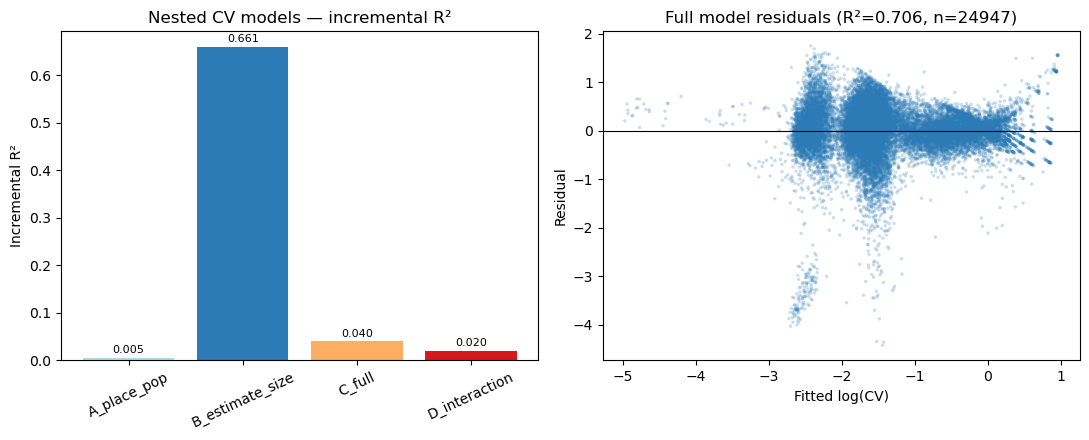

Saved C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook\data\processed\eda07_cumulative_r2.png


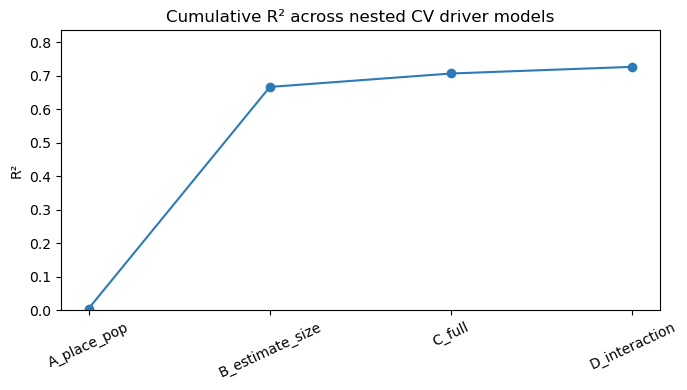

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Incremental R2
axes[0].bar(
    r2_table["model"],
    r2_table["incremental_r2"],
    color=["#abd9e9", "#2c7bb6", "#fdae61", "#d7191c"],
)
axes[0].set_ylabel("Incremental R²")
axes[0].set_title("Nested CV models — incremental R²")
axes[0].tick_params(axis="x", rotation=25)
for i, v in enumerate(r2_table["incremental_r2"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

# Residual vs fitted for full model
axes[1].scatter(
    models[2].fitted,
    models[2].residuals,
    s=6,
    alpha=0.25,
    c="#2c7bb6",
    edgecolors="none",
)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Fitted log(CV)")
axes[1].set_ylabel("Residual")
axes[1].set_title(
    f"Full model residuals (R²={models[2].r_squared:.3f}, n={models[2].n_obs})"
)
fig.tight_layout()
out = PROCESSED / "eda07_nested_r2_and_residuals.png"
fig.savefig(out, dpi=150)
print("Saved", out)
plt.show()

# Cumulative R2 chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r2_table["model"], r2_table["r_squared"], marker="o", color="#2c7bb6")
ax.set_ylabel("R²")
ax.set_title("Cumulative R² across nested CV driver models")
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, min(1.05, r2_table["r_squared"].max() * 1.15))
fig.tight_layout()
out2 = PROCESSED / "eda07_cumulative_r2.png"
fig.savefig(out2, dpi=150)
print("Saved", out2)
plt.show()


## 3. Matched estimate-size panel (Part B upgrade)

Compare Black 65+ aggregate, poverty counts, and total population **within shared estimate-size bins** at tract level. Matched on magnitude, not demographic twins.


,variable_group,size_bin,n,median_estimate,median_cv,share_cv_le_0_30
0,black65_agg,Q1 smallest,1130,29.0,0.800,0.004
1,black65_agg,Q2,409,186.0,0.334,0.357
2,black65_agg,Q3,57,557.0,0.225,0.860
3,population,Q1 smallest,5,35.0,0.760,0.200
4,population,Q2,2,124.0,0.236,1.000
5,population,Q3,684,2680.0,0.093,1.000
6,population,Q4 largest,1481,4814.0,0.075,0.999
7,poverty,Q1 smallest,353,63.0,0.513,0.042
8,poverty,Q2,1069,223.0,0.397,0.127
9,poverty,Q3,738,695.0,0.322,0.377


Saved C:\Users\justu\OneDrive\Desktop\MSBA\Capstone\Census_Uncertainty_Analysis-worktrees\granular-error-drivers-notebook\data\processed\eda07_matched_estimate_size.png


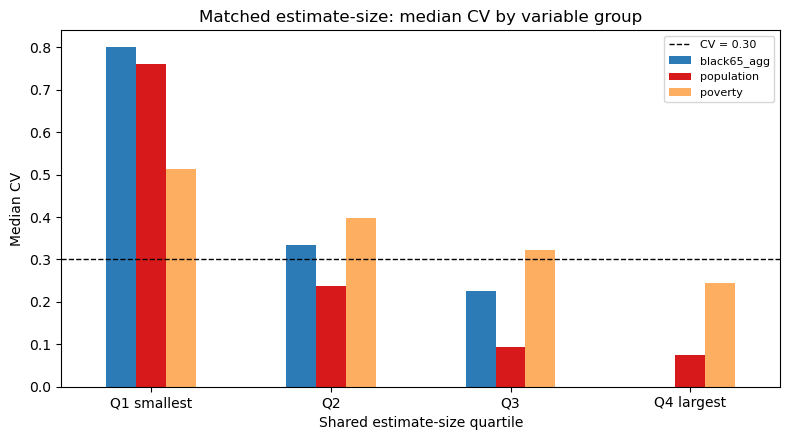

Mid-bin mean of median CVs — population: 0.165; black65_agg: 0.279
Matched-size assertion passed.


In [5]:
tract = ready[
    (ready["level"] == "tract")
    & (ready["variable_group"].isin(["population", "poverty", "black65_agg"]))
].copy()

# Shared bins from the pooled estimate-size distribution of the three groups.
tract["size_bin"] = pd.qcut(
    tract["estimate_size"],
    q=4,
    labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"],
    duplicates="drop",
)

rows = []
for (grp, b), sub in tract.groupby(["variable_group", "size_bin"], observed=True):
    rows.append(
        {
            "variable_group": grp,
            "size_bin": str(b),
            "n": len(sub),
            "median_estimate": sub["estimate_size"].median(),
            "median_cv": sub["cv"].median(),
            "share_cv_le_0_30": (sub["cv"] <= 0.30).mean(),
        }
    )
matched = pd.DataFrame(rows)
display(matched.round(3))

# Pivot for chart: median CV by bin × group
pivot = matched.pivot(
    index="size_bin", columns="variable_group", values="median_cv"
).reindex(["Q1 smallest", "Q2", "Q3", "Q4 largest"])

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind="bar", ax=ax, color=["#2c7bb6", "#d7191c", "#fdae61"])
ax.axhline(0.30, color="black", ls="--", lw=1, label="CV = 0.30")
ax.set_ylabel("Median CV")
ax.set_xlabel("Shared estimate-size quartile")
ax.set_title("Matched estimate-size: median CV by variable group")
ax.legend(title="", fontsize=8)
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
out = PROCESSED / "eda07_matched_estimate_size.png"
fig.savefig(out, dpi=150)
print("Saved", out)
plt.show()

# Within overlapping mid bins, Black 65+ should be noisier than population
# if size alone does not fully explain subgroup CV.
mid = matched[matched["size_bin"].isin(["Q2", "Q3"])]
pop_mid = mid.loc[mid["variable_group"] == "population", "median_cv"].mean()
b65_mid = mid.loc[mid["variable_group"] == "black65_agg", "median_cv"].mean()
print(f"Mid-bin mean of median CVs — population: {pop_mid:.3f}; black65_agg: {b65_mid:.3f}")
assert b65_mid > pop_mid, (
    "expected Black 65+ noisier than population in matched mid-size bins"
)
print("Matched-size assertion passed.")


## 4. Composite V2 — income residual flag on the sampling axis

Keep the EDA 06 matrix. Add `cv_residual_high`: income CV worse than predicted from household-universe size. Allocation axis unchanged; no DHC privacy join.


In [6]:
KEYS = ["STATE", "COUNTY", "TRACT"]
acs_tract = acs.load_level("tract")
alloc_tract = alloc.derive_rates(alloc.load_level("tract"))
df = acs_tract.merge(
    alloc_tract[KEYS + ["income_alloc", "B99192_001E"]],
    on=KEYS,
    how="inner",
    validate="one_to_one",
)
df["cv_income"] = acs.cv(df["B19013_001E"], df["B19013_001M"]).mask(
    acs.flag_topcoded_income(df)
)
df["hh"] = df["B99192_001E"]

rel, thr = build_reliability_frame(
    df, cv_col="cv_income", alloc_col="income_alloc"
)
rel, resid_meta = attach_cv_residual_flag(
    rel, cv_col="cv_income", estimate_size_col="hh"
)

counts = quadrant_counts(rel["quadrant"])
n = int(counts.sum())
print("Matrix thresholds:", {k: round(v, 4) for k, v in thr.items()})
print("Residual model:", {k: round(v, 4) if isinstance(v, float) else v for k, v in resid_meta.items()})
print(f"cv_residual_high share: {rel['cv_residual_high'].mean():.1%}")

# Among high-CV tracts, how often is the CV *unexpected* given HH size?
high_cv = rel["cv_income"] > thr["cv_threshold"]
print(
    "Among high-CV tracts, residual-high share:",
    f"{rel.loc[high_cv, 'cv_residual_high'].mean():.1%}",
)
# Blind-spot tracts that are also residual-high (sampling looks fine but
# imputation high; residual flag should be rare there by construction).
blind = rel["quadrant"] == "low_cv_high_alloc"
print(
    "Blind-spot tracts also residual-high:",
    f"{rel.loc[blind, 'cv_residual_high'].mean():.1%}",
)

assert n > 2000
assert rel["cv_residual_high"].any()
print("Composite V2 assertions passed.")


Matrix thresholds: {'cv_threshold': 0.3, 'alloc_threshold': 0.4643, 'alloc_percentile': 0.75}
Residual model: {'r_squared': 0.0113, 'residual_threshold': 0.3608, 'residual_percentile': 0.75, 'n_train': 2109.0, 'slope_log_estimate_size': -0.1434}
cv_residual_high share: 24.2%
Among high-CV tracts, residual-high share: 100.0%
Blind-spot tracts also residual-high: 28.3%
Composite V2 assertions passed.


## 5. Findings (plain English)

1. **Place population alone still fails** in the pooled frame (R² ≈ 0.005) — reproducing the JL Final Takeaway.
2. **Estimate size dominates the pooled model** (R² jumps to ≈ 0.67 alone; full model ≈ 0.71; interaction ≈ 0.73). Variable group and geography level add smaller but real incremental R².
3. **Matched estimate-size bins:** in mid-size quartiles, Black 65+ median CV stays higher than population (~0.28 vs ~0.17). Size matters, but table/variable structure still matters. (Population barely appears in the smallest shared bins because tract populations are large.)
4. **Composite V2:** keep the CV × allocation matrix. The income `cv_residual_high` flag is implemented as a tooltip seed, but the income-only size model has **very low R² (~0.01)** — household count does not predict income CV the way count-size predicts count CVs. For income, residual flags largely track raw high CV; they are more informative for count variables.

### Mentor question
Prefer residual-based sampling flags (best for count estimates) alongside raw CV tiers, or raw CV only for the dashboard — especially for income medians?


In [7]:
print("EDA 07 complete.")
print("R2 table:")
print(r2_table.to_string(index=False))
print("Charts:", sorted(p.name for p in PROCESSED.glob("eda07_*.png")))


EDA 07 complete.
R2 table:
          model  r_squared  incremental_r2  n_obs
    A_place_pop   0.005080        0.005080  24947
B_estimate_size   0.666121        0.661041  24947
         C_full   0.706222        0.040101  24947
  D_interaction   0.726025        0.019804  24947
Charts: ['eda07_cumulative_r2.png', 'eda07_matched_estimate_size.png', 'eda07_nested_r2_and_residuals.png']
